# K-NearestNeighbour Assignment

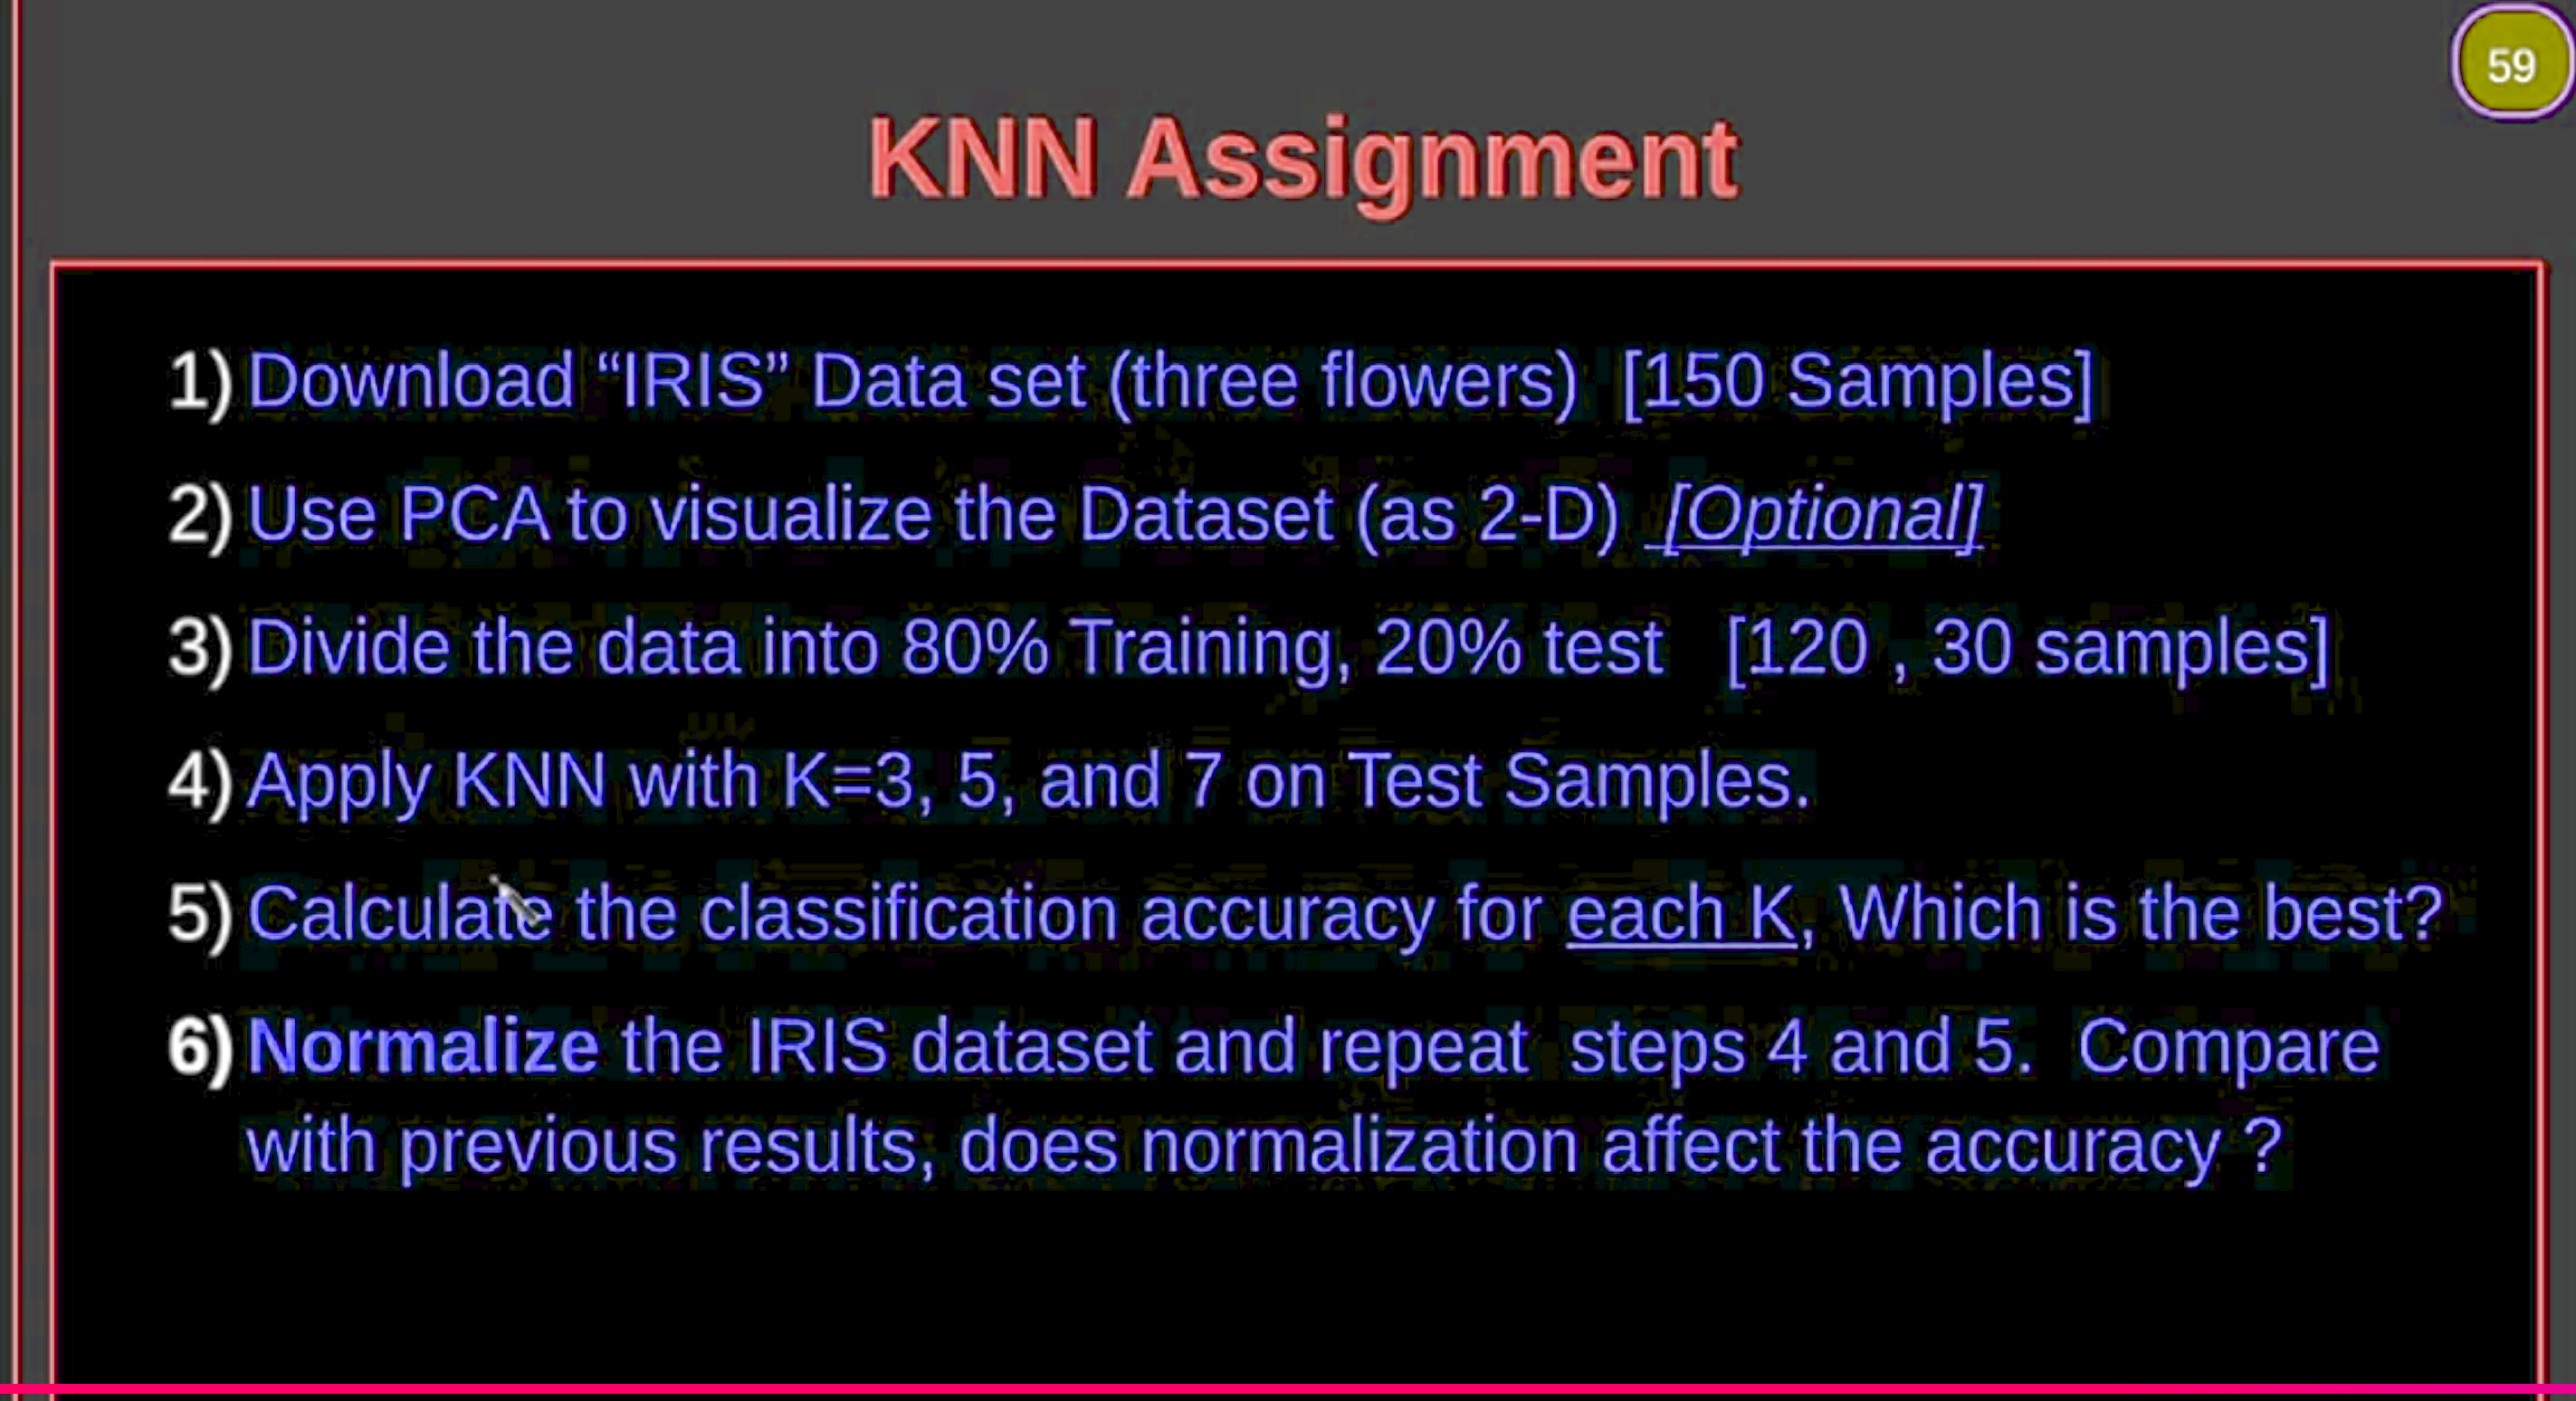

## Preparing the Data

In [36]:
from pandas import read_csv

iris_data = read_csv("iris_data.csv")
iris_data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [37]:
TRAINING_DATA_RATIO = 0.8

training_data_count = int(len(iris_data) * TRAINING_DATA_RATIO)
training_data = iris_data.sample(training_data_count)
training_data

,sepal_length,sepal_width,petal_length,petal_width,species
73,6.1,2.8,4.7,1.2,Iris-versicolor
47,4.6,3.2,1.4,0.2,Iris-setosa
52,6.9,3.1,4.9,1.5,Iris-versicolor
112,6.8,3.0,5.5,2.1,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
...,...,...,...,...,...
36,5.5,3.5,1.3,0.2,Iris-setosa
58,6.6,2.9,4.6,1.3,Iris-versicolor
101,5.8,2.7,5.1,1.9,Iris-virginica
94,5.6,2.7,4.2,1.3,Iris-versicolor


In [38]:
testing_data = iris_data.drop(training_data.index)
testing_data

,sepal_length,sepal_width,petal_length,petal_width,species
6,4.6,3.4,1.4,0.3,Iris-setosa
15,5.7,4.4,1.5,0.4,Iris-setosa
16,5.4,3.9,1.3,0.4,Iris-setosa
21,5.1,3.7,1.5,0.4,Iris-setosa
27,5.2,3.5,1.5,0.2,Iris-setosa
29,4.7,3.2,1.6,0.2,Iris-setosa
31,5.4,3.4,1.5,0.4,Iris-setosa
32,5.2,4.1,1.5,0.1,Iris-setosa
39,5.1,3.4,1.5,0.2,Iris-setosa
48,5.3,3.7,1.5,0.2,Iris-setosa


## Testing the Model

### Using my Custom KNN Implementation

In [39]:
from pandas import DataFrame, Series

from knn import KNNClassifier


def test_classifier_with_k(k: int, nomralise: bool) -> DataFrame:
    classifier = KNNClassifier(k, training_data, "species", False, nomralise)

    def test_row(r: Series) -> Series:
        predeicted_label = classifier.classify(r.drop("species"))
        return Series(
            {
                "original": r["species"],
                "predicted": predeicted_label,
                "accurate": predeicted_label == r["species"],
            }
        )

    test_results = testing_data.apply(test_row, axis=1)
    return test_results

In [40]:
DataFrame({
    "k": [3, 5, 7],
    "accuracy without normalisation": [
        test_classifier_with_k(3, False).value_counts("accurate")[True] / len(testing_data),
        test_classifier_with_k(5, False).value_counts("accurate")[True] / len(testing_data),
        test_classifier_with_k(7, False).value_counts("accurate")[True] / len(testing_data),
    ],
    "accuracy with normalisation": [
        test_classifier_with_k(3, True).value_counts("accurate")[True] / len(testing_data),
        test_classifier_with_k(5, True).value_counts("accurate")[True] / len(testing_data),
        test_classifier_with_k(7, True).value_counts("accurate")[True] / len(testing_data),
    ],
})

,k,accuracy without normalisation,accuracy with normalisation
0,3,0.933333,0.900000
1,5,0.933333,0.966667
2,7,0.900000,0.900000


Different results are observed everytime a new data split is created. This indicates the dataset is too small. Variations are mostly between 90% and 100% accuracy. Normalisation seems to mostly not affect the results, though sometimes it does.

### Using Scikit-Learn

In [41]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier()

classifier.fit(training_data.drop(columns=["species"]), training_data["species"])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['Iris-setosa','Iris-versicolor','Iris-virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [42]:
from knn import Standardiser

unclassified_training_data = training_data.drop(columns=["species"])
unclassified_testing_data = testing_data.drop(columns=["species"])

standardiser = Standardiser(unclassified_training_data)
nomralised_training_data = standardiser.standardied_data()
normalised_testing_data = unclassified_testing_data.apply(
    lambda r: standardiser.standardise_sample(r), axis="columns"
)

unnormalised_classifier = KNeighborsClassifier()
normalised_classifier = KNeighborsClassifier()

unnormalised_classifier.fit(unclassified_training_data, training_data["species"])
normalised_classifier.fit(nomralised_training_data, training_data["species"])


def test_classifier_with_k(k: int, normalise: bool) -> float:
    classifier = normalised_classifier if normalise else unnormalised_classifier
    _testing_data = normalised_testing_data if normalise else unclassified_testing_data

    classifier.set_params(n_neighbors=k)
    predictions = classifier.predict(_testing_data)
    
    accuracy = testing_data["species"] == predictions
    return accuracy.value_counts()[True] / len(testing_data)

In [43]:
DataFrame(
    {
        "k": [3, 5, 7],
        "accuracy without normalisation": [
            test_classifier_with_k(3, False),
            test_classifier_with_k(5, False),
            test_classifier_with_k(7, False),
        ],
        "accuracy with normalisation": [
            test_classifier_with_k(3, True),
            test_classifier_with_k(5, True),
            test_classifier_with_k(7, True),
        ],
    }
)

,k,accuracy without normalisation,accuracy with normalisation
0,3,0.933333,0.933333
1,5,0.933333,0.933333
2,7,0.966667,0.933333


While the results are not the exact same as for my custom implementation, the same trends seme to surface here as well